# <u>Métodos No Supervisados - Parte 3</u>

# Segmentación RFM y PAM

[Caso] Consiste en conocer a tus clientes a traves de los consumos que realiza en los centros comerciales con su tarjeta de crédito, analice bajo la metodología RFM (experto - analítico) y proponga cuáles serían los segmentos comerciales.

### 1. Librerias:

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import calendar
import seaborn as sns

### 2. Funciones:

Importante para el tratamiento de fechas

In [10]:
def convStrDate(cadena):
    cadena = str(cadena)
    fec = cadena[0:4]+'-'+cadena[4:7]+'-01'
    return fec

In [11]:
def add_months(date, months):
    month = date.month - 1 + months
    year = date.year + month // 12
    month = month % 12 + 1
    day = min(date.day, calendar.monthrange(year,month)[1])
    return datetime.date(year, month, day)

### 3. Extracción Base de Datos:

Extraemos la base de datos de consumo, en este caso no se considerarálos rubros, ya que, trataremos de aprovechar la esencia de las variables básicas como es la periodicidad y monto

In [12]:
dataFramePre = pd.read_csv(r"base de datos\02dataBaseConsumo.txt",delimiter='|', encoding='latin-1')
dataFramePre = dataFramePre.drop(['grupoGiro'],axis=1)
dataFramePre.head()

,codmes,cliente,edad,ingreso,sexo,flgLimaProv,flgAfBxi,monto,trx
0,201611,32572,[1. <=25],[2. <=1500],F,1.0,1.0,12,1
1,201611,29843,[1. <=25],[3. <=2500],F,0.0,1.0,22,1
2,201611,30033,[2. <=30],[2. <=1500],F,0.0,1.0,10,1
3,201612,3847,[7. > 55],[3. <=2500],M,1.0,0.0,350,4
4,201611,33131,[1. <=25],[2. <=1500],F,1.0,1.0,65,2


Creamos la base de datos con todos los periodos (histórico) de consumo e incluimos una variable de índice (ind) para los posteriores tratamientos.

In [13]:
# Creamos un campo de fecha para que nos ayudar a tratar la agregación i disminución de meses
dataFrame = pd.DataFrame()
dataFrame = dataFramePre.copy()

dataFrame['fecha'] = dataFramePre['codmes'].apply(convStrDate)
dataFrame['fecha'] = pd.to_datetime(dataFrame['fecha'])

# Creamos Base de Datos con las variables de interés:
dbGroup = dataFrame.groupby(['fecha','cliente']).agg({'trx':sum,'monto':sum})
dbGroup['ind'] = 1
dbGroup = dbGroup.reset_index()

C:\Users\dg_su\AppData\Local\Temp\ipykernel_24744\977794008.py:9: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  dbGroup = dataFrame.groupby(['fecha','cliente']).agg({'trx':sum,'monto':sum})


In [14]:
dbGroup.head()

,fecha,cliente,trx,monto,ind
0,2016-11-01,1,5,266,1
1,2016-11-01,2,8,453,1
2,2016-11-01,3,7,1676,1
3,2016-11-01,4,15,1186,1
4,2016-11-01,6,1,4,1


### 4. Universo:

Elegiremos una cosecha referente que servirá como nuestro universo de clientes el cual analizaremos su comportamiento, esta cosecha puede ser un mes o varios meses.
 - Recordar: tiene que ser a nivel de cliente

In [15]:
# Fecha mínima y máximo:
print(dbGroup['fecha'].min())
print(dbGroup['fecha'].max())

# Filtramos la cosecha para el universo:
dbUniv = dbGroup[dbGroup['fecha']=='2017-10-01']
dbUniv = dbUniv.rename(columns={'fecha':'periodo'})
dbUniv = dbUniv[['periodo','cliente']]
dbUniv.head()

2016-11-01 00:00:00
2017-10-01 00:00:00


,periodo,cliente
150227,2017-10-01,1
150228,2017-10-01,2
150229,2017-10-01,3
150230,2017-10-01,4
150231,2017-10-01,5


Para poder relacionar nuestra base Universo con la base histórica de consumo, vamos agregar las fechas anteriores (-1, -2, -3) para que posteriormente podamos hacer merge

In [16]:
# Incluiremos fechas de los 3 últimos meses 
for i in range(3):
    dbUniv['fec_'+str(i+1)] =\
    pd.to_datetime(dbUniv.apply(lambda x: add_months(x['periodo'],-(i+1)),axis=1))
dbUniv.head()

,periodo,cliente,fec_1,fec_2,fec_3
150227,2017-10-01,1,2017-09-01,2017-08-01,2017-07-01
150228,2017-10-01,2,2017-09-01,2017-08-01,2017-07-01
150229,2017-10-01,3,2017-09-01,2017-08-01,2017-07-01
150230,2017-10-01,4,2017-09-01,2017-08-01,2017-07-01
150231,2017-10-01,5,2017-09-01,2017-08-01,2017-07-01


### 5. Desarrollo Base de Datos para el RFM:

Pegamos la información de Tenencia y de consumo de los 3 últimos meses

In [17]:
dbFinal = pd.merge(dbUniv,dbGroup[['fecha','cliente','monto','trx','ind']], how='left',
                   left_on=['fec_1','cliente'],right_on = ['fecha','cliente'])
dbFinal = pd.merge(dbFinal,dbGroup[['fecha','cliente','monto','trx','ind']], how='left',
                   left_on=['fec_2','cliente'],right_on = ['fecha','cliente'])
dbFinal = pd.merge(dbFinal,dbGroup[['fecha','cliente','monto','trx','ind']], how='left',
                   left_on=['fec_3','cliente'],right_on = ['fecha','cliente'])

In [18]:
dbFinal['M_1'] = dbFinal['ind_x'].apply(lambda x: 1 if x==1 else 0)
dbFinal['monto_1'] = dbFinal['monto_x'].fillna(0)

dbFinal['M_2'] = dbFinal['ind_y'].apply(lambda x: 1 if x==1 else 0)
dbFinal['monto_2'] = dbFinal['monto_y'].fillna(0)

dbFinal['M_3'] = dbFinal['ind'].apply(lambda x: 1 if x==1 else 0)
dbFinal['monto_3'] = dbFinal['monto'].fillna(0)

dbFinal = dbFinal[['periodo','cliente','M_1','M_2','M_3','monto_1','monto_2','monto_3']]

In [19]:
dbFinal.head()

,periodo,cliente,M_1,M_2,M_3,monto_1,monto_2,monto_3
0,2017-10-01,1,0,1,1,0.0,210.0,346.0
1,2017-10-01,2,1,0,0,228.0,0.0,0.0
2,2017-10-01,3,1,1,1,1691.0,586.0,255.0
3,2017-10-01,4,1,1,1,2650.0,1701.0,601.0
4,2017-10-01,5,0,1,0,0.0,7.0,0.0


#### 5.1 Formando R + F + M

A partir de la información de los 3 últimos meses damos forma a las variables R, F y M usando la libreria numpy para trabajar las condiciones

In [20]:
dbFinal['frec'] = dbFinal['M_1']+dbFinal['M_2']+dbFinal['M_3']
dbFinal['rec'] = np.where(dbFinal['M_1']==1,3,np.where(dbFinal['M_2']==1,2,np.where(dbFinal['M_3']==1,1,0)))
dbFinal['monto3um'] = np.where(dbFinal['frec']>0,
                               (dbFinal['monto_1']+dbFinal['monto_2']+dbFinal['monto_3'])/dbFinal['frec'],0)

Para el caso del Monto que es variable continua, existen varias formas de tratar los cortes, pueden ser por medio del clustering (kmeans), por deciles, la mediana o promedio, este paso tiene que ver con el negocio el cual podrian dar propuesta de cuantos niveles de mosnto es lo relevante

In [21]:
'''Analizando el valor de "MONTO"
- Mediana
- Clustering (kmeans)
- Deciles
- Promedio'''
corte = dbFinal['monto3um'][dbFinal['monto3um']>0].median()
print(f'La mediana de Monto es: {corte}')

La mediana de Monto es: 165.33333333333334


In [22]:
### Realice el corte usando kmeans

#### 5.2 Etiqueta de Monto y filtros

Este paso es muy importante porque se hacen los últimos ajustes de la base de datos del RFM, suelen aparecer algunas anomalias, en caso sean mínimas podrian extraerse o corregir, en caso sea muy voluminoso habría que revisar la fuente de información 

In [23]:
dbFinal['monto'] = np.where(dbFinal['monto3um']>=corte,'alto',np.where(dbFinal['monto3um']>0,'bajo','None'))
dbFinal = dbFinal[['periodo','cliente','monto3um','rec','frec','monto']]
# Limpiando
# Alt+126 (~)
dbFinal = dbFinal[~((dbFinal['frec']>0) & (dbFinal['monto3um']==0))]

#### 5.3 Distribución RFM

Este paso nos dará la propuesta de la primera distribución o los grupos propuestos donde nuestros clientes están almacenados, es aquí donde surge el debate y analizan cuales serían los grupos finales para el negocio.

In [24]:
#nTotal = dbFinal.count()[0]
#dbRfm = dbFinal.groupby(['rec','frec','monto']).agg({'cliente':'count'}).sort_values(by=['rec','frec'], ascending=False)
nTotal = dbFinal[dbFinal['rec']>0].count()[0]
resumRfm = dbFinal[dbFinal['rec']>0].groupby(['rec','frec','monto']).agg({'cliente':'count'})\
                                 .sort_values(by=['rec','frec'], ascending=False)

resumRfm = resumRfm.reset_index()
resumRfm['%'] = round(100*resumRfm['cliente']/nTotal,1)
print(f'Clientes Total: {nTotal}\n')
print(resumRfm)

Clientes Total: 10806

    rec  frec monto  cliente     %
0     3     3  alto     3083  28.5
1     3     3  bajo     1900  17.6
2     3     2  alto      871   8.1
3     3     2  bajo     1161  10.7
4     3     1  alto      479   4.4
5     3     1  bajo      901   8.3
6     2     2  alto      474   4.4
7     2     2  bajo      523   4.8
8     2     1  alto      242   2.2
9     2     1  bajo      433   4.0
10    1     1  alto      257   2.4
11    1     1  bajo      482   4.5


C:\Users\dg_su\AppData\Local\Temp\ipykernel_24744\4022660796.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nTotal = dbFinal[dbFinal['rec']>0].count()[0]


# HASTA AQUI YA SE TIENE EL 70% DEL ESTUDIO !!!

### 6. RFM método Clásico o Experto

A partir de la base de datos construída, y luego de analizar las distribuciones, se concluirán los nombres de los grupos conjuntamente con las características de la frecuencia, recencia y monto.

Este análisis se realizó teniendo en cuenta la experiencia del analista en el negocio el cual puede identificar los grupos con la información dada y apuntando lo que necesita.

# Herramienta PAM
- Partitioning Around Medoids

### 1. Librerias:

In [25]:
#!pip install kmodes

In [26]:
from kmodes.kmodes import KModes
from sklearn import preprocessing

### 2. Base de Datos y etiquetado:

Al preparar la base de datos, es necesario que las variables categóricas tengan una etiqueta, para ello haremos uso del LabelEncoder()

In [27]:
dbRfm = pd.DataFrame()
dbRfm = dbFinal[dbFinal['rec']>0].copy()

dbKmodes = pd.DataFrame()
dbKmodes = dbRfm.copy()

cod = preprocessing.LabelEncoder()
dbKmodes = dbKmodes[['rec','frec','monto']].apply(cod.fit_transform)

### 3. Modelo Clustering:

Realizamos varias pruebas de clustering con el algorimo KMedois, cuyo algoritmo trabaja con variables categóricas.

In [28]:
cost=[]
cluster=[]

for i in list(range(1,9)):
    model = KModes(n_clusters=i, init='Cao', n_init=1, verbose=1)
    cluster.append(model.fit_predict(dbKmodes))
    cost.append(model.cost_)
print(model.cluster_centroids_)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 13634.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 8318.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 523, cost: 6605.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 257, cost: 5606.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 257, cost: 3706.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 3449.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 2578.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration:

### 4. Evolución de Cluster Vs Costo:

Este gráfico nos ayudará a analizar la evolución de los valores del costo cada vez que sugiere cierto número de cluster, lo ideal es tomar aquellos costos menores

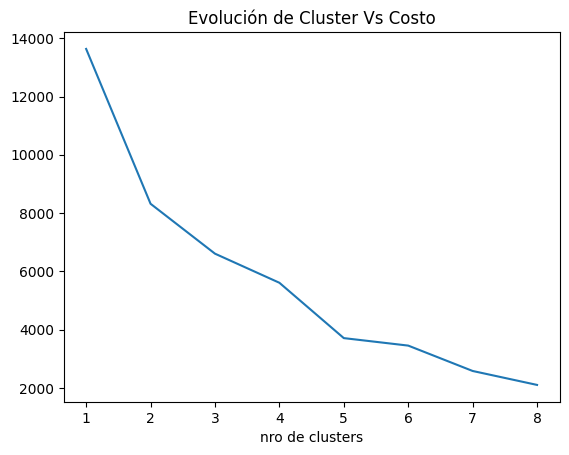

In [29]:
rango=np.array(range(1,len(cost)+1))
plt.plot(rango,cost)
plt.title('Evolución de Cluster Vs Costo')
plt.xlabel('nro de clusters')
plt.show()

### 5. Análisis de Clusters:

In [30]:
numClus=[2,3,4,5,6,7]

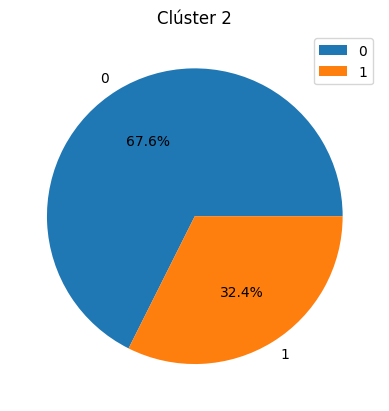

         ctdCliente  pctCliente
cluster                        
0              7306       67.61
1              3500       32.39




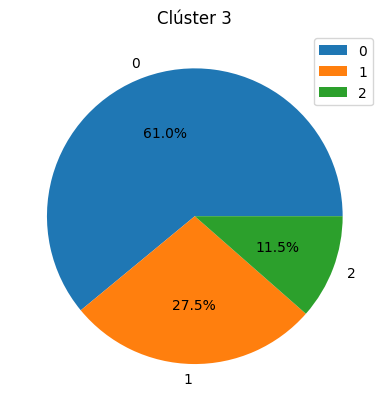

         ctdCliente  pctCliente
cluster                        
0              6590       60.98
1              2977       27.55
2              1239       11.47




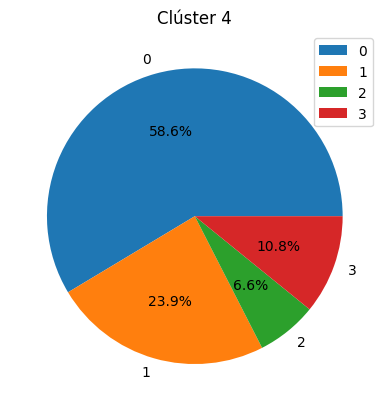

         ctdCliente  pctCliente
cluster                        
0              6333       58.61
1              2585       23.92
2               716        6.63
3              1172       10.85




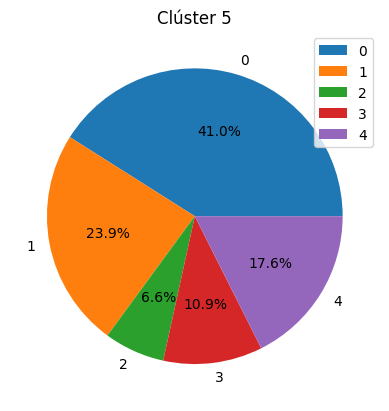

         ctdCliente  pctCliente
cluster                        
0              4433       41.02
1              2585       23.92
2               716        6.63
3              1172       10.85
4              1900       17.58




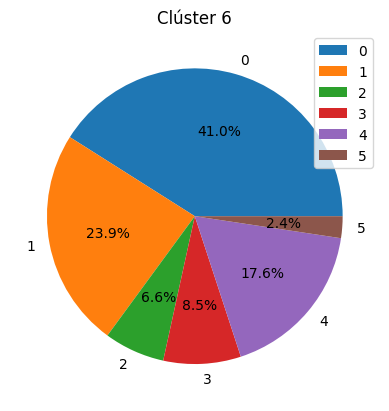

         ctdCliente  pctCliente
cluster                        
0              4433       41.02
1              2585       23.92
2               716        6.63
3               915        8.47
4              1900       17.58
5               257        2.38




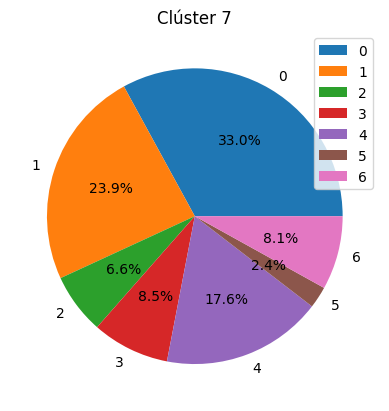

         ctdCliente  pctCliente
cluster                        
0              3562       32.96
1              2585       23.92
2               716        6.63
3               915        8.47
4              1900       17.58
5               257        2.38
6               871        8.06




In [31]:
copy =  pd.DataFrame()
for i in numClus:
    # Distribución de los grupos por clúster:
    copy['cluster'] = cluster[i-1]
    ctdGrupo =  pd.DataFrame()
    ctdGrupo['ctdCliente']=copy.groupby('cluster').size()
    ctdGrupo['pctCliente']=np.round(100*ctdGrupo['ctdCliente']/ctdGrupo['ctdCliente'].sum(),2)
   
    # gráfico de los grupos según su distribución:
    plt.pie(ctdGrupo['pctCliente'], labels=ctdGrupo.index, autopct='%1.1f%%')
    plt.title('Clúster '+str(i))
    plt.legend()
    plt.show()
    print(ctdGrupo)      
    print('\n')

### 6. Base Final - Cluster

Una vez analizado el conjunto de cluster, procedemos a elegir el que mas se ajusta a nuestros propósitos y luego agregamos esas etiquetas en nuestra base oficial para continuar con la asignación de nombres de segmentos.

In [32]:
nCluster = int(input('Ingrese la cantidad de cluster: '))

In [33]:
df = pd.DataFrame()
df = dbRfm.copy()
# Agregamos la etiqueta de los clusters:
df['cluster'] = cluster[nCluster-1]

### 7. RFM Método Analítico:

#### 7.1 Características de los clusters:

A partir de las carcterísticas agrupados por los cluster, procedemos a analizar quienes son y con ello llegar a la conclusión.

In [34]:
resClus = df.groupby('cluster').agg({'cliente':'count','rec':'mean','frec':'mean','monto3um':'mean'})\
                                 .sort_values(by='cluster')
resClus = resClus.reset_index()
resClus['%'] = round(100*resClus['cliente']/dbRfm.count()[0],1)
print(f'Clientes Total: {dbRfm.count()[0]}\n')
print(resClus)

Clientes Total: 10806

   cluster  cliente       rec      frec    monto3um     %
0        0     4433  3.000000  2.587413  821.748365  41.0
1        1     2585  2.797679  1.651451   64.602128  23.9
2        2      716  2.000000  1.662011  716.140363   6.6
3        3     1172  1.369454  1.000000  199.212457  10.8
4        4     1900  3.000000  3.000000   80.344035  17.6


C:\Users\dg_su\AppData\Local\Temp\ipykernel_24744\3004282222.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  resClus['%'] = round(100*resClus['cliente']/dbRfm.count()[0],1)
C:\Users\dg_su\AppData\Local\Temp\ipykernel_24744\3004282222.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'Clientes Total: {dbRfm.count()[0]}\n')
